In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [7]:
df=pd.read_csv("../../understanding-data/train.csv",usecols=["Age","Fare", "Survived"])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [8]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [9]:
x=df.drop(columns=["Survived"])
y=df["Survived"]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
x_train["age_imputed"]=x_train["Age"]
x_test["age_imputed"]=x_test["Age"]

In [37]:
x_train['age_imputed'][x_train['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['age_imputed'][x_test['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

/var/folders/x4/dcd672b95h70g_8b6vm4lcp40000gn/T/ipykernel_17660/3205950695.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['age_imputed'][x_train['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().

In [40]:
x_train.sample(5),x_test.sample(5)

(      Age      Fare  age_imputed
 766   NaN   39.6000         25.0
 103  33.0    8.6542         33.0
 118  24.0  247.5208         24.0
 508  28.0   22.5250         28.0
 71   16.0   46.9000         16.0,
       Age     Fare  age_imputed
 168   NaN  25.9250         21.0
 465  38.0   7.0500         38.0
 790   NaN   7.7500         28.0
 538   NaN  14.5000         32.0
 5     NaN   8.4583         37.0)

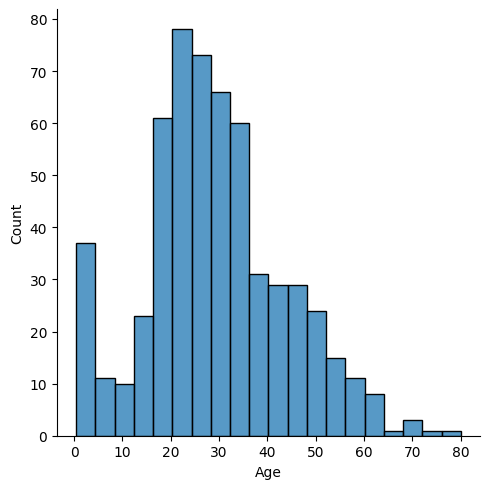

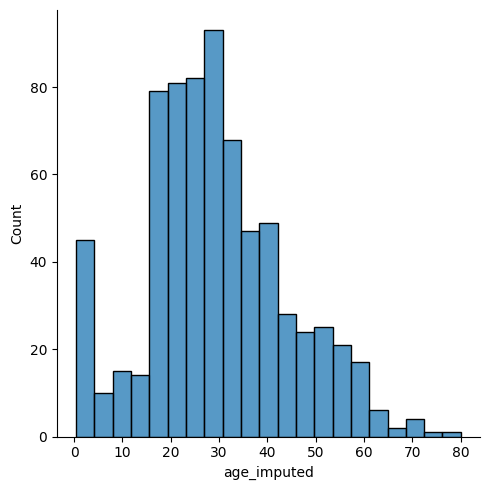

In [42]:

sns.displot(x_train["Age"],label="orginal")
sns.displot(x_train["age_imputed"],label="imputed")
plt.show()

In [43]:
x_train.cov()

,Age,Fare,age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,60.089962
age_imputed,210.251707,60.089962,210.562046


In [44]:
data = pd.read_csv("train.csv",usecols=["GarageQual", "FireplaceQu", "SalePrice"])

In [45]:
x=data
y=data["SalePrice"]

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [61]:
x_train["garage_imputed"]=x_train["GarageQual"]
x_test["garage_imputed"]=x_test["GarageQual"]

x_train["fireplace_imputed"]= x_train["FireplaceQu"]
x_test["fireplace_imputed"]= x_test["FireplaceQu"]


In [74]:
x_train["fireplace_imputed"][x_train["fireplace_imputed"].isnull()] = x_train["FireplaceQu"].dropna().sample(x_train["fireplace_imputed"].isnull().sum()).values
x_train["garage_imputed"][x_train["garage_imputed"].isnull()] = x_train["GarageQual"].dropna().sample(x_train["GarageQual"].isnull().sum()).values

/var/folders/x4/dcd672b95h70g_8b6vm4lcp40000gn/T/ipykernel_17660/2543283076.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train["fireplace_imputed"][x_train["fireplace_imputed"].isnull()] = x_train["FireplaceQu"].dropna().sample(x_tr

In [100]:
x_train.sample(10)

,FireplaceQu,GarageQual,SalePrice,garage_imputed,fireplace_imputed
547,NaN,TA,129500,TA,TA
1303,NaN,TA,232000,TA,Gd
752,NaN,TA,217000,TA,TA
329,NaN,Fa,78000,Fa,Gd
1287,NaN,TA,190000,TA,Gd
825,Gd,TA,385000,TA,Gd
897,NaN,TA,142953,TA,TA
652,TA,TA,191000,TA,TA
968,NaN,NaN,37900,TA,Gd
467,Gd,TA,146500,TA,Gd


In [102]:
temp=pd.concat([
    x_train["GarageQual"].value_counts()/len(x_train["GarageQual"].dropna()),
    x_train["garage_imputed"].value_counts()/len(x_train)
],axis=1)
temp.columns=["original","imputed"]
temp

,original,imputed
TA,0.951087,0.953767
Fa,0.032609,0.030822
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712
